## IMPORT

In [1]:
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display_html
import numpy as np
import datetime as dt

## PATH

In [2]:
# data path
ROOT = Path.cwd().parent

data_path = ROOT / 'data'

## LOAD DATA

In [3]:
# read data
df_norm = pd.read_csv(data_path / 'dati_normalizzati.csv').drop(columns=['total'])
df = pd.read_csv(data_path / 'dati_assoluti.csv')

## LOTKA VOLTERRA BASICO

In [4]:
df = df_norm

In [5]:
df = df.drop(columns = ['Europe'])

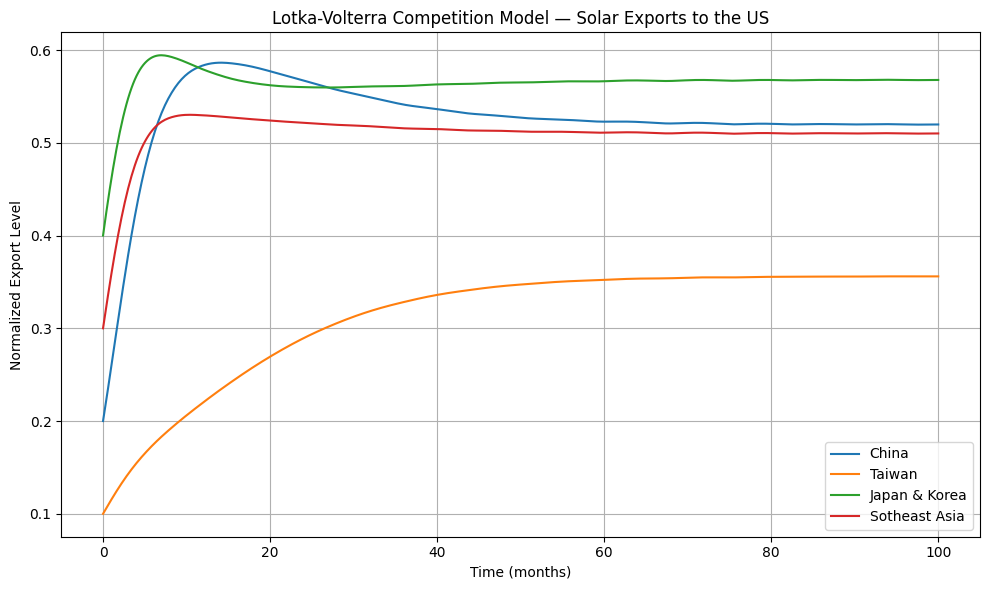

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# first try run with fake data
def lotka_volterra_4_explicit(t, X, r1, r2, r3, r4,
                               a12, a13, a14,
                               a21, a23, a24,
                               a31, a32, a34,
                               a41, a42, a43):
    x1, x2, x3, x4 = X

    # assuming that carrying capacity is 1 talking about market share
    dx1dt = r1 * x1 * (1 - x1 - a12 * x2 - a13 * x3 - a14 * x4)
    dx2dt = r2 * x2 * (1 - a21 * x1 - x2 - a23 * x3 - a24 * x4)
    dx3dt = r3 * x3 * (1 - a31 * x1 - a32 * x2 - x3 - a34 * x4)
    dx4dt = r4 * x4 * (1 - a41 * x1 - a42 * x2 - a43 * x3 - x4)

    return [dx1dt, dx2dt, dx3dt, dx4dt]

# fake Parameters
params = {
    'r1': 0.5, 'r2': 0.3, 'r3': 0.4, 'r4': 0.45,
    'a12': 0.6, 'a13': 0.2, 'a14': 0.3,
    'a21': 0.3, 'a23': 0.5, 'a24': 0.4,
    'a31': 0.4, 'a32': 0.2, 'a34': 0.3,
    'a41': 0.3, 'a42': 0.3, 'a43': 0.4
}

# fake Initial conditions
X0 = [0.2, 0.1, 0.4, 0.3] 

# Time span and evaluation points
t_span = (0, 100)
t_eval = np.linspace(*t_span, 500)

# Solve the system
sol = solve_ivp(
    fun=lambda t, X: lotka_volterra_4_explicit(t, X, **params),
    t_span=t_span,
    y0=X0,
    t_eval=t_eval,
)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='China')
plt.plot(sol.t, sol.y[1], label='Taiwan')
plt.plot(sol.t, sol.y[2], label='Japan & Korea')
plt.plot(sol.t, sol.y[3], label='Sotheast Asia')
plt.title('Lotka-Volterra Competition Model — Solar Exports to the US')
plt.xlabel('Time (months)')
plt.ylabel('Normalized Export Level')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## CALIBRATION

In [7]:
from scipy.optimize import least_squares

china_data = df['China']
taiwan_data = df['Taiwan']
jp_kr_data = df['JP+KR']
se_data = df['SoutheastAsia']

# Stack data
data = np.vstack([china_data, taiwan_data, jp_kr_data, se_data]) 
t_data = np.linspace(0, len(china_data)-1, len(china_data))  

In [8]:
def residuals(p_array, X0, t_data, data):
    # Unpack parameters from flat array (in the order defined)
    r1, r2, r3, r4 = p_array[:4]
    a12, a13, a14 = p_array[4:7]
    a21, a23, a24 = p_array[7:10]
    a31, a32, a34 = p_array[10:13]
    a41, a42, a43 = p_array[13:]

    # Solve the system
    sol = solve_ivp(
        fun=lambda t, X: lotka_volterra_4_explicit(t, X,
                                                   r1, r2, r3, r4,
                                                   a12, a13, a14,
                                                   a21, a23, a24,
                                                   a31, a32, a34,
                                                   a41, a42, a43),
        t_span=(t_data[0], t_data[-1]),
        y0=X0,
        t_eval=t_data,
    )

    # Check for integration failure
    if sol.y.shape[1] != len(t_data):
        return np.ones(data.size) * 1e6

    # Return residuals
    return (sol.y - data).ravel()


In [9]:
from scipy.optimize import least_squares

# Initial guess for parameters
initial_guess = [
    0.5, 0.3, 0.4, 0.35,     # r1, r2, r3, r4
    0.6, 0.2, 0.1,           # a12, a13, a14
    0.3, 0.5, 0.2,           # a21, a23, a24
    0.4, 0.2, 0.3,           # a31, a32, a34
    0.2, 0.4, 0.3            # a41, a42, a43
]


# Initial export levels from data
X0 = data[:, 0]

# Parameter bounds
lower_bounds = [0] * 16
upper_bounds = [2] * 16

# Fit the model to data
result = least_squares(
    residuals,
    initial_guess,
    args=(X0, t_data, data),
    bounds=(lower_bounds, upper_bounds)
)

# Extract fitted parameters
fitted_params = result.x


In [10]:
param_names = [
    'r1', 'r2', 'r3', 'r4',
    'a12', 'a13', 'a14',
    'a21', 'a23', 'a24',
    'a31', 'a32', 'a34',
    'a41', 'a42', 'a43',
]

# Create dictionary
fitted_dict = {name: val for name, val in zip(param_names, fitted_params)}

# print parameters and tuned value
for k, v in fitted_dict.items():
    print(f"{k}: {v:.6f}")

r1: 0.326772
r2: 0.271448
r3: 1.645853
r4: 0.640060
a12: 0.876767
a13: 0.673520
a14: 1.543209
a21: 1.085909
a23: 0.798055
a24: 1.350972
a31: 1.093928
a32: 1.343592
a34: 1.063891
a41: 1.308102
a42: 0.000000
a43: 1.190709


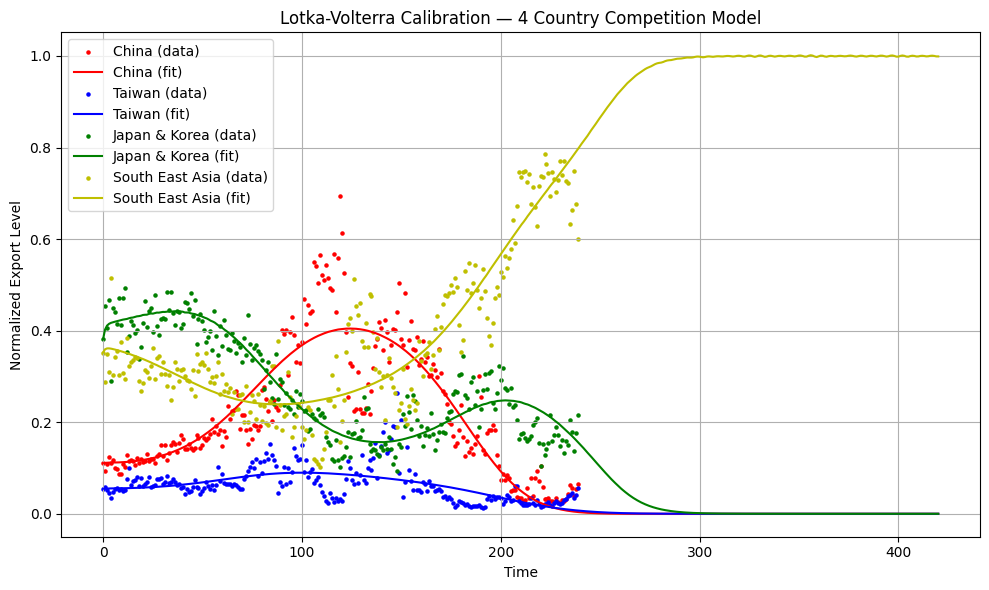

In [11]:
simulated_t_data = np.linspace(0, 420, 420)

# Solve the system using the fitted parameters
sol = solve_ivp(
    fun=lambda t, X: lotka_volterra_4_explicit(t, X, *fitted_params),
    t_span=(simulated_t_data[0], simulated_t_data[-1]),
    y0=X0,
    t_eval=simulated_t_data
)

# Plot results
plt.figure(figsize=(10, 6))
colors = ['r', 'b', 'g', 'y']
labels = ['China', 'Taiwan', 'Japan & Korea', 'South East Asia']

for i in range(4):
    plt.scatter(t_data, data[i], color=colors[i], s=5, label=f'{labels[i]} (data)')
    plt.plot(simulated_t_data, sol.y[i], f'{colors[i]}-', label=f'{labels[i]} (fit)')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Normalized Export Level')
plt.title('Lotka-Volterra Calibration — 4 Country Competition Model')
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
import plotly.graph_objects as go

colors = ['red', 'blue', 'green', 'orange']
labels = ['China', 'Taiwan', 'Japan & Korea', 'South East Asia']

fig = go.Figure()

# Add data (scatter) and fit (line) for each species
for i in range(4):
    fig.add_trace(go.Scatter(
        x=t_data, y=data[i],
        mode='markers',
        marker=dict(size=5, color=colors[i]),
        name=f'{labels[i]} (data)'
    ))
    fig.add_trace(go.Scatter(
        x=simulated_t_data, y=sol.y[i],
        mode='lines',
        line=dict(color=colors[i]),
        name=f'{labels[i]} (fit)'
    ))

# Layout
fig.update_layout(
    title='Lotka-Volterra Calibration — 4 Country Competition Model',
    xaxis_title='Time',
    yaxis_title='Normalized Export Level',
    legend_title = 'Region',
    template='plotly_white',
    height=600,
    width=900
)

fig.show()
